# 07 -- Repeated Locus-Held-Out Splits: Robustness of the Main Experiment

Reviewer concern (major #4): the entire study rests on a **single** 70:15:15
locus-held-out split, with relatively few independent test loci (70 hotspot,
67 rare). The observed ~10-11 point C>T frequency shift between the hotspot
train and test sets (Results -> Dataset Characteristics) is consistent with
sampling variation at this locus count, but a single split can't distinguish
"this particular split happened to be unusual" from "the result is stable
across resamplings."

This notebook re-splits the 906 loci (same clustered, strand-corrected data
as every other notebook -- nothing about the dataset itself changes) using
5 new random seeds, retrains the identical primary 21bp CNN on each,
evaluates on each split's own held-out test set, and combines with the
original seed=42 result (already trained in notebook 01) for 6 independent
splits per dataset. All other hyperparameters (architecture, weighted loss,
optimiser, early stopping) are held fixed -- only which loci fall into
train/val/test is varied, isolating split sensitivity from training
stochasticity.

In [1]:
SEED = 42
import random, numpy as np, torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [2]:
import os
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data import CLASSES, load_position_table, load_cluster_table, MutationDataset, position_majority_ceiling
from src.model import SimpleCNN, count_trainable_params
from src.train import compute_class_weights, train_model, predict
from src.metrics import (
    compute_all_metrics, majority_baseline, mcnemar_test,
    cluster_paired_bootstrap_test, cluster_wilcoxon_paired_test,
)

WINDOW_SIZE = 21
DATASETS = ['hotspot', 'rare']
REPEAT_SEEDS = [43, 44, 45, 46, 47]   # 5 new split seeds; combined with the existing seed=42 run -> 6 splits total
ORIGINAL_SEED = 42

TEST_SIZE = 0.15
VAL_SIZE = 0.15

PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MAIN_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'main')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'repeated_splits')
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project root:  {PROJECT_ROOT}")
print(f"Repeat seeds:  {REPEAT_SEEDS} (+ original seed {ORIGINAL_SEED})")
print(f"Results dir:   {RESULTS_DIR}")
print(f"Device:        {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == 'cuda' else ""))


Project root:  C:\Users\danya\Documents\projects\tp53_mutation_subtype
Repeat seeds:  [43, 44, 45, 46, 47] (+ original seed 42)
Results dir:   C:\Users\danya\Documents\projects\tp53_mutation_subtype\results\repeated_splits
Device:        cuda (NVIDIA GeForce RTX 5090)


## Load the shared, already-corrected inputs

Same `cluster_table.csv` / `position_table.csv` / windowed instance data used
everywhere else -- only the train/val/test partition of the 906 loci changes
across repeats, never the loci, clusters, or sequences themselves.

In [3]:
cluster_table = load_cluster_table(os.path.join(PROCESSED_DIR, 'cluster_table.csv'))
position_table = load_position_table(os.path.join(PROCESSED_DIR, 'position_table.csv'))
position_to_cluster = position_table.set_index('position_id')['cluster_id']

combined_w21 = pd.read_csv(
    os.path.join(PROCESSED_DIR, f'tp53_mutation_dataset_w{WINDOW_SIZE}.csv'),
    dtype={'position_id': str},
)

hotspot_clusters = cluster_table[cluster_table['hotspot_flag']]
rare_clusters = cluster_table[~cluster_table['hotspot_flag']]
assert not (set(hotspot_clusters['cluster_id']) & set(rare_clusters['cluster_id']))

print(f"906-locus table loaded: {len(hotspot_clusters)} hotspot, {len(rare_clusters)} rare clusters")
print(f"Window-21bp instance data: {len(combined_w21):,} rows")


906-locus table loaded: 461 hotspot, 445 rare clusters
Window-21bp instance data: 693,428 rows


## Splitting function (identical logic to `data_pipeline.ipynb` Stage 6/7/8, parameterised by seed)

Stratified by each cluster's majority subtype, 70:15:15, then expanded to
`position_id` and joined to the window-21 instance data -- exactly the
procedure used to build the canonical seed-42 split, just re-run with a
different `random_state`.

In [4]:
def stratified_cluster_split(cluster_df, id_col='cluster_id', strata_col='majority_subtype',
                              test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=42):
    ids = np.asarray(cluster_df[id_col].to_numpy(), dtype=object)
    strata = np.asarray(cluster_df[strata_col].to_numpy(), dtype=object)

    train_val_ids, test_ids = train_test_split(
        ids, test_size=test_size, stratify=strata, random_state=random_state
    )
    train_val_df = cluster_df[cluster_df[id_col].isin(train_val_ids)]
    train_ids, val_ids = train_test_split(
        np.asarray(train_val_df[id_col].to_numpy(), dtype=object),
        test_size=val_size / (1 - test_size),
        stratify=np.asarray(train_val_df[strata_col].to_numpy(), dtype=object),
        random_state=random_state,
    )
    train_ids, val_ids, test_ids = set(train_ids), set(val_ids), set(test_ids)
    assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
    return train_ids, val_ids, test_ids


def build_split_dataframes(seed):
    """Returns {dataset_name: {'train'/'val'/'test': DataFrame}} for one split seed,
    joined to window-21 instance data (position_id, Sequence, MutationType)."""
    result = {}
    for name, clusters in (('hotspot', hotspot_clusters), ('rare', rare_clusters)):
        train_c, val_c, test_c = stratified_cluster_split(clusters, random_state=seed)
        result[name] = {}
        for split_name, cids in (('train', train_c), ('val', val_c), ('test', test_c)):
            pos_ids = set(position_to_cluster[position_to_cluster.isin(cids)].index)
            df = (
                combined_w21[combined_w21['position_id'].isin(pos_ids)]
                [['position_id', 'Sequence', 'MutationType']]
                .reset_index(drop=True)
            )
            result[name][split_name] = df
    return result


# Sanity check against the canonical seed-42 split before trusting this for new seeds:
# re-deriving seed=42 here must reproduce the existing data/splits/window_21 files exactly.
_check = build_split_dataframes(ORIGINAL_SEED)
for name in DATASETS:
    existing_test = pd.read_csv(
        os.path.join(PROJECT_ROOT, 'data', 'splits', f'window_{WINDOW_SIZE}', name, 'test.csv'),
        dtype={'position_id': str},
    )
    rederived_ids = set(_check[name]['test']['position_id'])
    existing_ids = set(existing_test['position_id'])
    assert rederived_ids == existing_ids, (
        f"{name}: re-deriving seed={ORIGINAL_SEED} in this notebook doesn't match "
        "the canonical data/splits/window_21 test set -- splitting logic has diverged."
    )
print("OK: re-deriving seed=42 here exactly reproduces the canonical notebook-01 test split.")


OK: re-deriving seed=42 here exactly reproduces the canonical notebook-01 test split.


## Train + evaluate the primary 21bp CNN on each of the 5 new split seeds

Identical architecture, loss weighting, optimiser, and early-stopping
criterion to notebook 01 -- the only thing that varies across repeats is
`build_split_dataframes(seed)`'s train/val/test partition of the 906 loci.
`train_model`'s own seed is left at its default (42) throughout, so weight
initialisation and batch shuffling are held fixed and only split composition
varies.

In [5]:
repeated_metrics = {}   # repeated_metrics[(seed, name)] -> metrics dict
repeated_models = {}

for seed in REPEAT_SEEDS:
    splits_seed = build_split_dataframes(seed)
    for name in DATASETS:
        train_df = splits_seed[name]['train']
        val_df = splits_seed[name]['val']
        test_df = splits_seed[name]['test']

        train_ds = MutationDataset(train_df)
        val_ds = MutationDataset(val_df)
        test_ds = MutationDataset(test_df)
        y_test = test_ds.y.numpy()

        class_weights = compute_class_weights(train_ds.y.numpy(), device=device)
        model = SimpleCNN()
        model, history = train_model(
            model, train_ds, val_ds, device,
            class_weights=class_weights, verbose=False,
        )

        cnn_preds, cnn_probs = predict(model, test_ds, device)

        y_train = train_ds.y.numpy()
        maj_preds, majority_class = majority_baseline(y_train, len(y_test))

        cluster_ids_test = position_to_cluster.loc[test_df['position_id']].values
        metrics = compute_all_metrics(y_test, cnn_preds, cluster_ids=cluster_ids_test)
        metrics['baselines'] = {
            'majority_accuracy': float((maj_preds == y_test).mean()),
            'majority_class': majority_class,
        }
        metrics['position_majority_ceiling'] = position_majority_ceiling(test_df)
        metrics['mcnemar_cnn_vs_majority'] = mcnemar_test(y_test, cnn_preds, maj_preds)
        metrics['cluster_test_cnn_vs_majority'] = {
            'bootstrap': cluster_paired_bootstrap_test(y_test, cnn_preds, maj_preds, cluster_ids_test),
            'wilcoxon': cluster_wilcoxon_paired_test(y_test, cnn_preds, maj_preds, cluster_ids_test),
        }
        metrics['n_test_instances'] = int(len(y_test))
        metrics['n_test_clusters'] = int(len(set(cluster_ids_test)))
        metrics['ct_pct_train'] = float((train_df['MutationType'] == 'C>T').mean())
        metrics['ct_pct_test'] = float((test_df['MutationType'] == 'C>T').mean())
        metrics['best_epoch'] = history['best_epoch']
        metrics['stopped_epoch'] = history['stopped_epoch']
        metrics['split_seed'] = seed

        repeated_metrics[(seed, name)] = metrics
        repeated_models[(seed, name)] = model

        print(f"seed={seed}  {name:<7}  n_test_clusters={metrics['n_test_clusters']:>3}  "
              f"accuracy={metrics['accuracy']:.4f}  mcc={metrics['mcc']:.4f}  "
              f"majority_acc={metrics['baselines']['majority_accuracy']:.4f}  "
              f"ct_test={metrics['ct_pct_test']:.4f}  (best_epoch={metrics['best_epoch']})")


seed=43  hotspot  n_test_clusters= 70  accuracy=0.0900  mcc=-0.0284  majority_acc=0.6848  ct_test=0.6848  (best_epoch=1)


seed=43  rare     n_test_clusters= 67  accuracy=0.1690  mcc=-0.0222  majority_acc=0.3611  ct_test=0.3611  (best_epoch=48)


seed=44  hotspot  n_test_clusters= 70  accuracy=0.1427  mcc=-0.0490  majority_acc=0.4539  ct_test=0.4539  (best_epoch=1)


seed=44  rare     n_test_clusters= 67  accuracy=0.2233  mcc=-0.0113  majority_acc=0.4281  ct_test=0.4281  (best_epoch=13)


seed=45  hotspot  n_test_clusters= 70  accuracy=0.1358  mcc=-0.0448  majority_acc=0.5202  ct_test=0.5202  (best_epoch=17)


seed=45  rare     n_test_clusters= 67  accuracy=0.2886  mcc=0.1105  majority_acc=0.3521  ct_test=0.3521  (best_epoch=7)


seed=46  hotspot  n_test_clusters= 70  accuracy=0.2897  mcc=0.0889  majority_acc=0.4962  ct_test=0.4962  (best_epoch=4)


seed=46  rare     n_test_clusters= 67  accuracy=0.2592  mcc=0.0643  majority_acc=0.3700  ct_test=0.3700  (best_epoch=24)


seed=47  hotspot  n_test_clusters= 70  accuracy=0.3613  mcc=0.1899  majority_acc=0.6215  ct_test=0.6215  (best_epoch=5)


seed=47  rare     n_test_clusters= 67  accuracy=0.1484  mcc=-0.0436  majority_acc=0.3507  ct_test=0.3507  (best_epoch=4)


## Combine with the original seed=42 run (notebook 01) for 6 splits total

In [6]:
all_seed_rows = []

for seed in REPEAT_SEEDS:
    for name in DATASETS:
        m = repeated_metrics[(seed, name)]
        all_seed_rows.append({
            'split_seed': seed, 'dataset': name,
            'accuracy': m['accuracy'], 'mcc': m['mcc'],
            'balanced_accuracy': m['balanced_accuracy'],
            'majority_accuracy': m['baselines']['majority_accuracy'],
            'n_test_clusters': m['n_test_clusters'],
            'n_test_instances': m['n_test_instances'],
            'ct_pct_train': m['ct_pct_train'], 'ct_pct_test': m['ct_pct_test'],
            'cnn_beats_majority': m['accuracy'] > m['baselines']['majority_accuracy'],
            'cluster_bootstrap_pvalue': m['cluster_test_cnn_vs_majority']['bootstrap']['pvalue'],
        })

# original seed=42 run, pulled from notebook 01's already-saved outputs
for name in DATASETS:
    main_m = json.load(open(os.path.join(MAIN_RESULTS_DIR, name, 'metrics.json')))
    train_df_orig = pd.read_csv(
        os.path.join(PROJECT_ROOT, 'data', 'splits', f'window_{WINDOW_SIZE}', name, 'train.csv')
    )
    test_df_orig = pd.read_csv(
        os.path.join(PROJECT_ROOT, 'data', 'splits', f'window_{WINDOW_SIZE}', name, 'test.csv')
    )
    all_seed_rows.append({
        'split_seed': ORIGINAL_SEED, 'dataset': name,
        'accuracy': main_m['accuracy'], 'mcc': main_m['mcc'],
        'balanced_accuracy': main_m['balanced_accuracy'],
        'majority_accuracy': main_m['baselines']['majority_accuracy'],
        'n_test_clusters': len(set(position_to_cluster.loc[test_df_orig['position_id']])),
        'n_test_instances': main_m['n_test_instances'],
        'ct_pct_train': float((train_df_orig['MutationType'] == 'C>T').mean()),
        'ct_pct_test': float((test_df_orig['MutationType'] == 'C>T').mean()),
        'cnn_beats_majority': main_m['accuracy'] > main_m['baselines']['majority_accuracy'],
        'cluster_bootstrap_pvalue': main_m['cluster_test']['cnn_vs_majority']['bootstrap']['pvalue'],
    })

all_seeds_df = pd.DataFrame(all_seed_rows).sort_values(['dataset', 'split_seed']).reset_index(drop=True)
all_seeds_path = os.path.join(RESULTS_DIR, 'per_split_results.csv')
all_seeds_df.to_csv(all_seeds_path, index=False)
print(f"6 splits x 2 datasets = {len(all_seeds_df)} rows -> {all_seeds_path}\n")
all_seeds_df


6 splits x 2 datasets = 12 rows -> C:\Users\danya\Documents\projects\tp53_mutation_subtype\results\repeated_splits\per_split_results.csv



,split_seed,dataset,accuracy,mcc,balanced_accuracy,majority_accuracy,n_test_clusters,n_test_instances,ct_pct_train,ct_pct_test,cnn_beats_majority,cluster_bootstrap_pvalue
0,42,hotspot,0.132200,0.066582,0.259782,0.649385,70,112511,0.479936,0.649385,False,0.014
1,43,hotspot,0.090008,-0.028395,0.204631,0.684804,70,142099,0.483789,0.684804,False,0.000
2,44,hotspot,0.142740,-0.049016,0.207446,0.453944,70,85211,0.534878,0.453944,False,0.004
3,45,hotspot,0.135797,-0.044752,0.195870,0.520246,70,91968,0.561083,0.520246,False,0.050
4,46,hotspot,0.289699,0.088911,0.315075,0.496240,70,105185,0.509031,0.496240,False,0.258
5,47,hotspot,0.361276,0.189947,0.303881,0.621462,70,87941,0.495428,0.621462,False,0.006
6,42,rare,0.218036,0.026101,0.198719,0.358171,67,2362,0.360121,0.358171,False,0.028
7,43,rare,0.169048,-0.022191,0.158816,0.361111,67,2520,0.368706,0.361111,False,0.002
8,44,rare,0.223301,-0.011314,0.166094,0.428067,67,2266,0.356061,0.428067,False,0.004
9,45,rare,0.288633,0.110524,0.269236,0.352065,67,2349,0.374297,0.352065,False,0.378


## Aggregate across the 6 splits: is the single-split result representative?

In [7]:
agg_rows = []
for name in DATASETS:
    sub = all_seeds_df[all_seeds_df['dataset'] == name]
    agg_rows.append({
        'dataset': name,
        'n_splits': len(sub),
        'accuracy_mean': sub['accuracy'].mean(), 'accuracy_std': sub['accuracy'].std(),
        'accuracy_min': sub['accuracy'].min(), 'accuracy_max': sub['accuracy'].max(),
        'mcc_mean': sub['mcc'].mean(), 'mcc_std': sub['mcc'].std(),
        'majority_accuracy_mean': sub['majority_accuracy'].mean(), 'majority_accuracy_std': sub['majority_accuracy'].std(),
        'ct_pct_test_mean': sub['ct_pct_test'].mean(), 'ct_pct_test_std': sub['ct_pct_test'].std(),
        'ct_pct_test_min': sub['ct_pct_test'].min(), 'ct_pct_test_max': sub['ct_pct_test'].max(),
        'n_splits_cnn_beats_majority': int(sub['cnn_beats_majority'].sum()),
        'n_splits_cluster_bootstrap_significant_at_05': int((sub['cluster_bootstrap_pvalue'] < 0.05).sum()),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = os.path.join(RESULTS_DIR, 'aggregate_summary.csv')
agg_df.to_csv(agg_path, index=False)
print(f"Aggregate summary -> {agg_path}\n")
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)
print(agg_df.to_string(index=False))

print("\nPlain-language readout:")
for _, row in agg_df.iterrows():
    print(f"\n{row['dataset']}:")
    print(f"  accuracy: {row['accuracy_mean']:.3f} +/- {row['accuracy_std']:.3f} "
          f"(range {row['accuracy_min']:.3f}-{row['accuracy_max']:.3f}) across {int(row['n_splits'])} splits")
    print(f"  majority baseline itself varies: {row['majority_accuracy_mean']:.3f} +/- {row['majority_accuracy_std']:.3f}")
    print(f"  test-set C>T%% varies: {row['ct_pct_test_mean']:.3f} +/- {row['ct_pct_test_std']:.3f} "
          f"(range {row['ct_pct_test_min']:.3f}-{row['ct_pct_test_max']:.3f})")
    print(f"  CNN beat majority baseline in {int(row['n_splits_cnn_beats_majority'])}/{int(row['n_splits'])} splits")
    print(f"  cluster-bootstrap CNN-vs-majority significant (p<0.05) in "
          f"{int(row['n_splits_cluster_bootstrap_significant_at_05'])}/{int(row['n_splits'])} splits")


Aggregate summary -> C:\Users\danya\Documents\projects\tp53_mutation_subtype\results\repeated_splits\aggregate_summary.csv

dataset  n_splits  accuracy_mean  accuracy_std  accuracy_min  accuracy_max  mcc_mean  mcc_std  majority_accuracy_mean  majority_accuracy_std  ct_pct_test_mean  ct_pct_test_std  ct_pct_test_min  ct_pct_test_max  n_splits_cnn_beats_majority  n_splits_cluster_bootstrap_significant_at_05
hotspot         6       0.191953      0.107483      0.090008      0.361276  0.037213 0.095206                0.571014               0.093284          0.571014         0.093284         0.453944         0.684804                            0                                             4
   rare         6       0.217764      0.052823      0.148404      0.288633  0.020630 0.058306                0.370022               0.029270          0.370022         0.029270         0.350733         0.428067                            0                                             4

Plain-language reado

## Figure: accuracy per split, with each split's own majority baseline

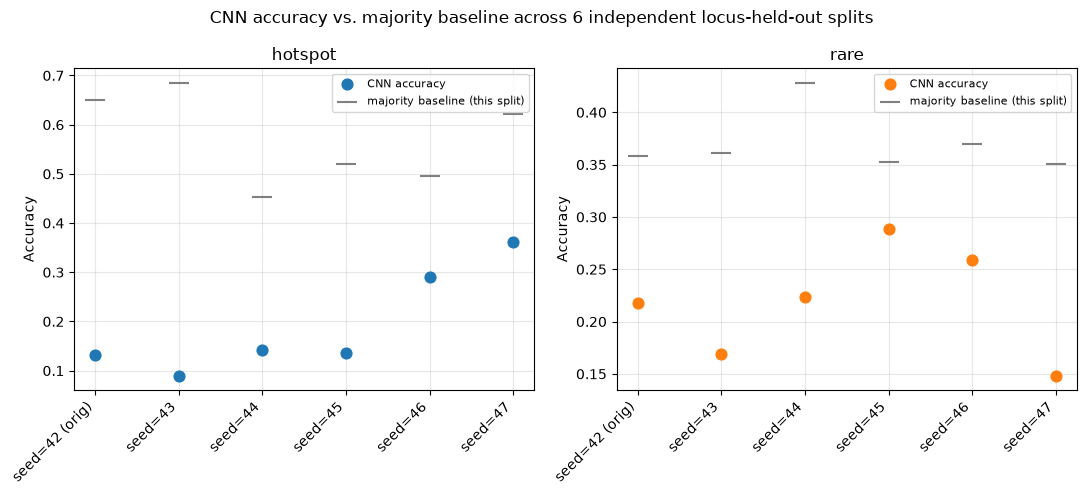

Figure -> C:\Users\danya\Documents\projects\tp53_mutation_subtype\results\repeated_splits\figure_accuracy_across_splits.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
colors = {'hotspot': 'tab:blue', 'rare': 'tab:orange'}

for ax, name in zip(axes, DATASETS):
    sub = all_seeds_df[all_seeds_df['dataset'] == name].sort_values('split_seed')
    x = range(len(sub))
    ax.scatter(x, sub['accuracy'], color=colors[name], label='CNN accuracy', zorder=3, s=60)
    ax.scatter(x, sub['majority_accuracy'], color='gray', marker='_', s=200,
               label='majority baseline (this split)', zorder=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"seed={s}" + (" (orig)" if s == ORIGINAL_SEED else "") for s in sub['split_seed']],
                        rotation=45, ha='right')
    ax.set_title(name)
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('CNN accuracy vs. majority baseline across 6 independent locus-held-out splits')
fig.tight_layout()
fig_path = os.path.join(RESULTS_DIR, 'figure_accuracy_across_splits.png')
fig.savefig(fig_path, dpi=200)
plt.show()
print(f"Figure -> {fig_path}")


## Save full per-split metrics (all fields, not just the summary table)

In [9]:
def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    return obj

full_path = os.path.join(RESULTS_DIR, 'full_metrics_by_seed.json')
serializable = {f"{seed}_{name}": _json_safe(m) for (seed, name), m in repeated_metrics.items()}
with open(full_path, 'w') as f:
    json.dump(serializable, f, indent=2)
print(f"Full per-split metrics -> {full_path}")


Full per-split metrics -> C:\Users\danya\Documents\projects\tp53_mutation_subtype\results\repeated_splits\full_metrics_by_seed.json
